本系列分享在Windows11下使用Conda PIP安装IsaacSim，有如下优点
* 免Windows Ubuntu双系统安装
* pip install issaacsim 十分方便
* 方便SolidWorks建模导出然后导入IsaacSim
  
也有如下缺点：
* ROS2使用不方便
* 算法通常运行在ubuntu系统下，需要迁移

> 本系列分享不涉及ROS2，完全在Conda环境中运行，因此也兼容Ubuntu系统。

# 一、环境配置

## (1) Windows相关配置

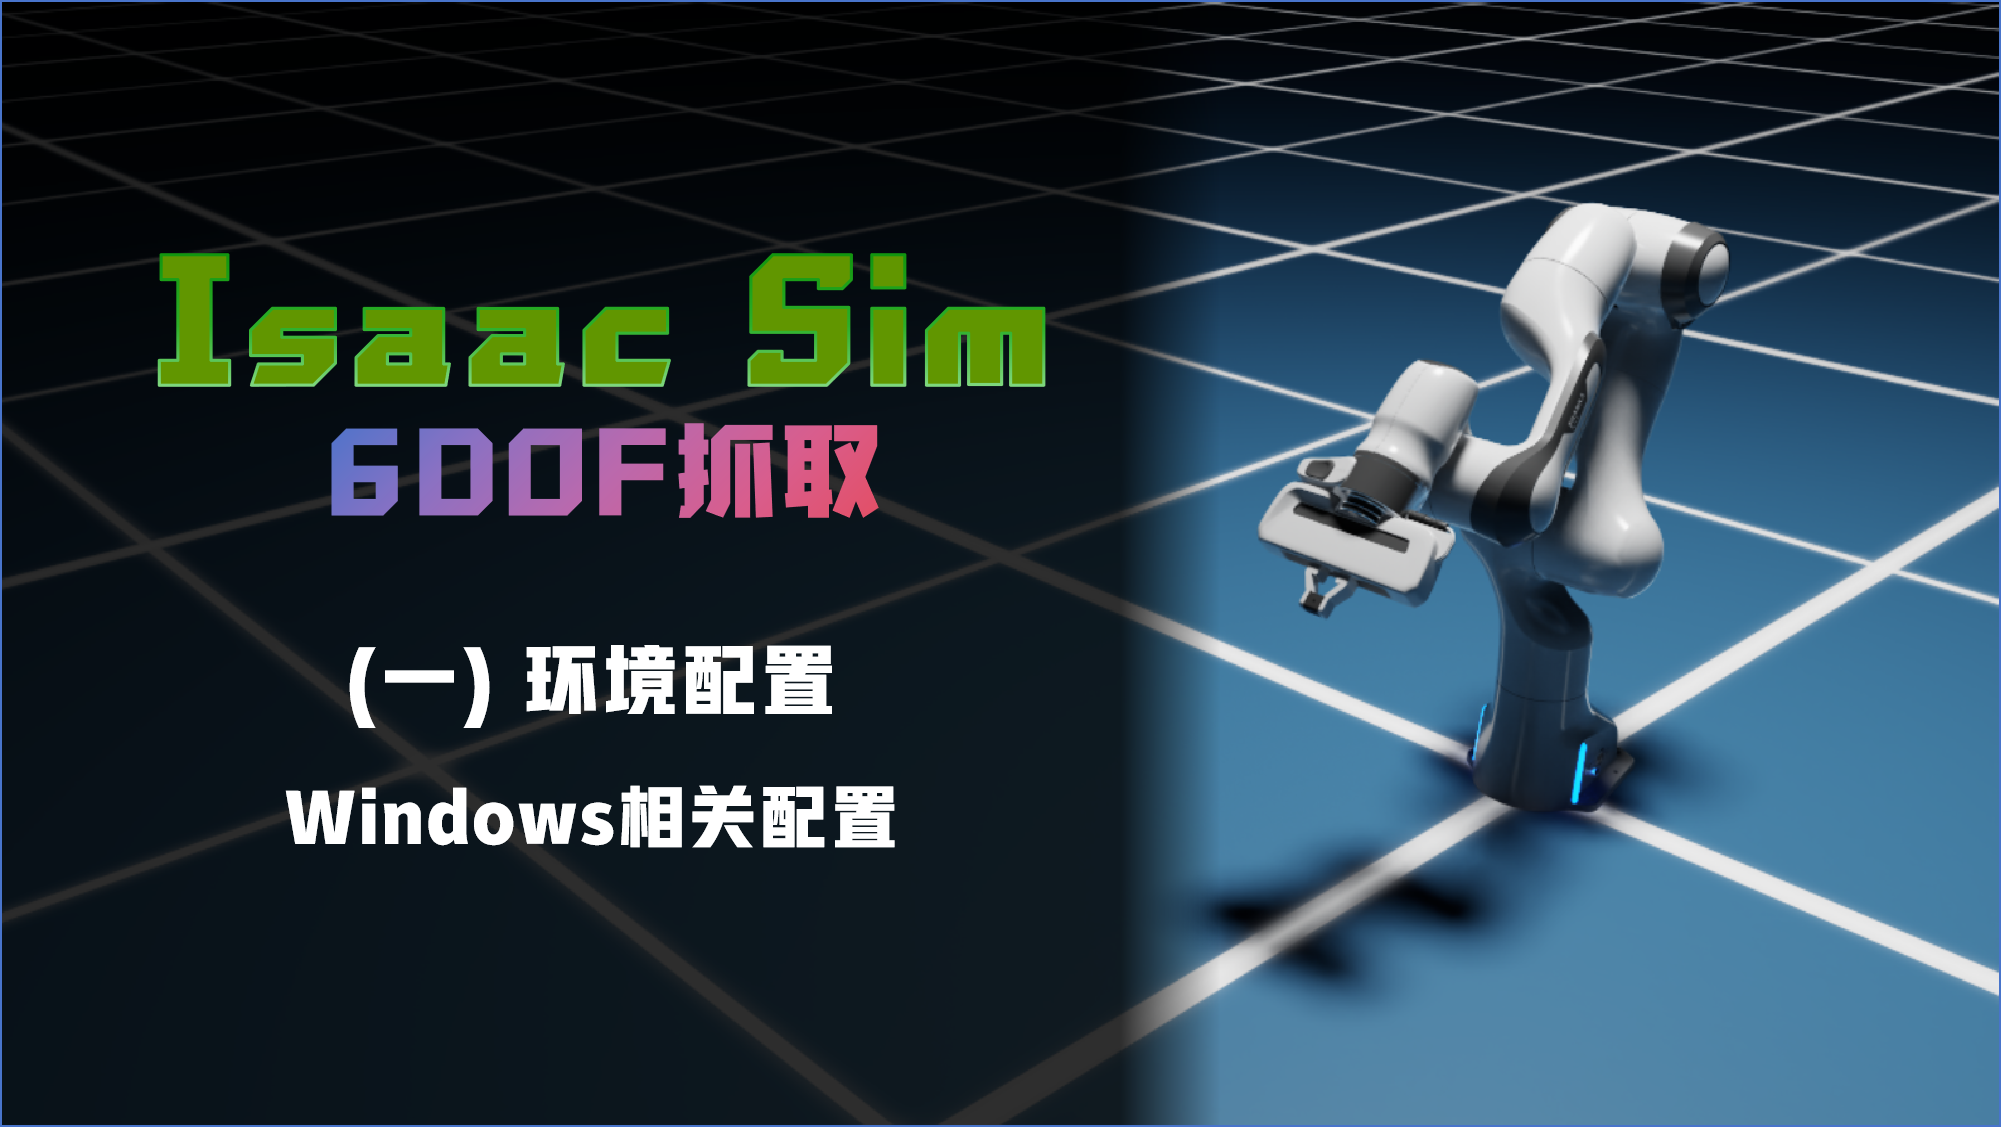


避免Windows系统下，无法安装IsaacSim与IsaacSim无法使用GPU的问题。

### 1. 启用Windows系统"长路径支持"
   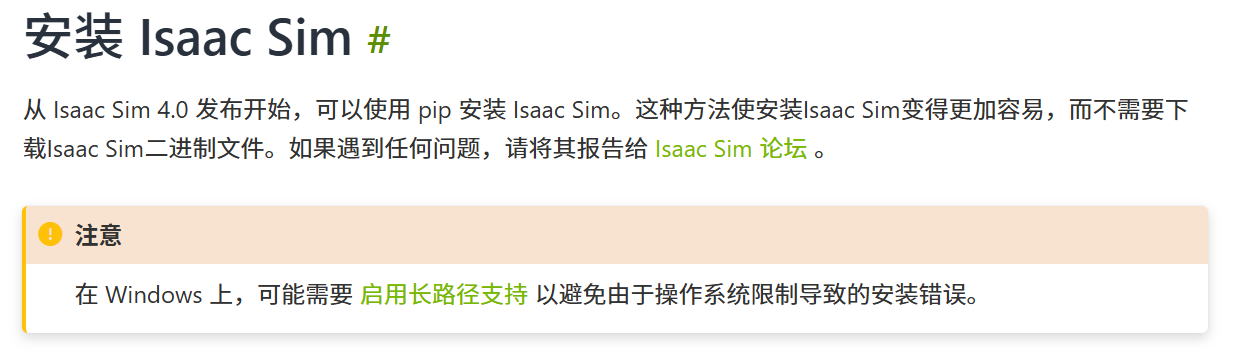


   [启用长路径支持](https://learn.microsoft.com/en-us/windows/win32/fileio/maximum-file-path-limitation?tabs=registry#enable-long-paths-in-windows-10-version-1607-and-later)

   以管理员身份运行powershell, 输入以下命令
   
   ```powershell
      New-ItemProperty -Path "HKLM:\SYSTEM\CurrentControlSet\Control\FileSystem" -Name "LongPathsEnabled" -Value 1 -PropertyType DWORD -Force
   ```
--- 


### 2. 修改IsaacSim的渲染api
   * IsaacSim的渲染方式有Vulkan和DirectX12两种，默认是Vulkan.
   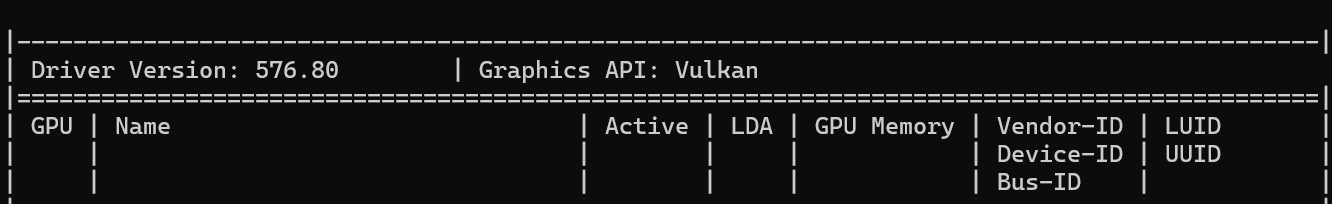
   * 而在Windows环境下，DirectX12会更加稳定，而Vulkan则有时出现运行崩溃的情况。
   
   值得了解的是，使用DirectX12 渲染 第一次运行IsaacSim时会用CPU编译着色器，需要多等待一会儿

   **修改方法**：
   1. 找到Anaconda/MiniConda的安装路径，找到IsaacSim的安装包
      ```bash
      F:\Python\intepreter\anaconda3\envs\env_isaaclab\Lib\site-packages\isaacsim
      ```
      * Anaconda/MiniConda的安装路径是F:\Python\intepreter\anaconda3，(对应需要找到自己的安装路径)
      * IsaacSim的虚拟环境路径是 envs\env_isaaclab
      * IsaacSim的安装包路径是 Lib\site-packages\isaacsim
   2. 使用VS Code打开 IsaacSim的安装文件夹
   3. 搜索apps 文件夹的kit文件中 vulkan = true
   4. 修改 vulkan = false
      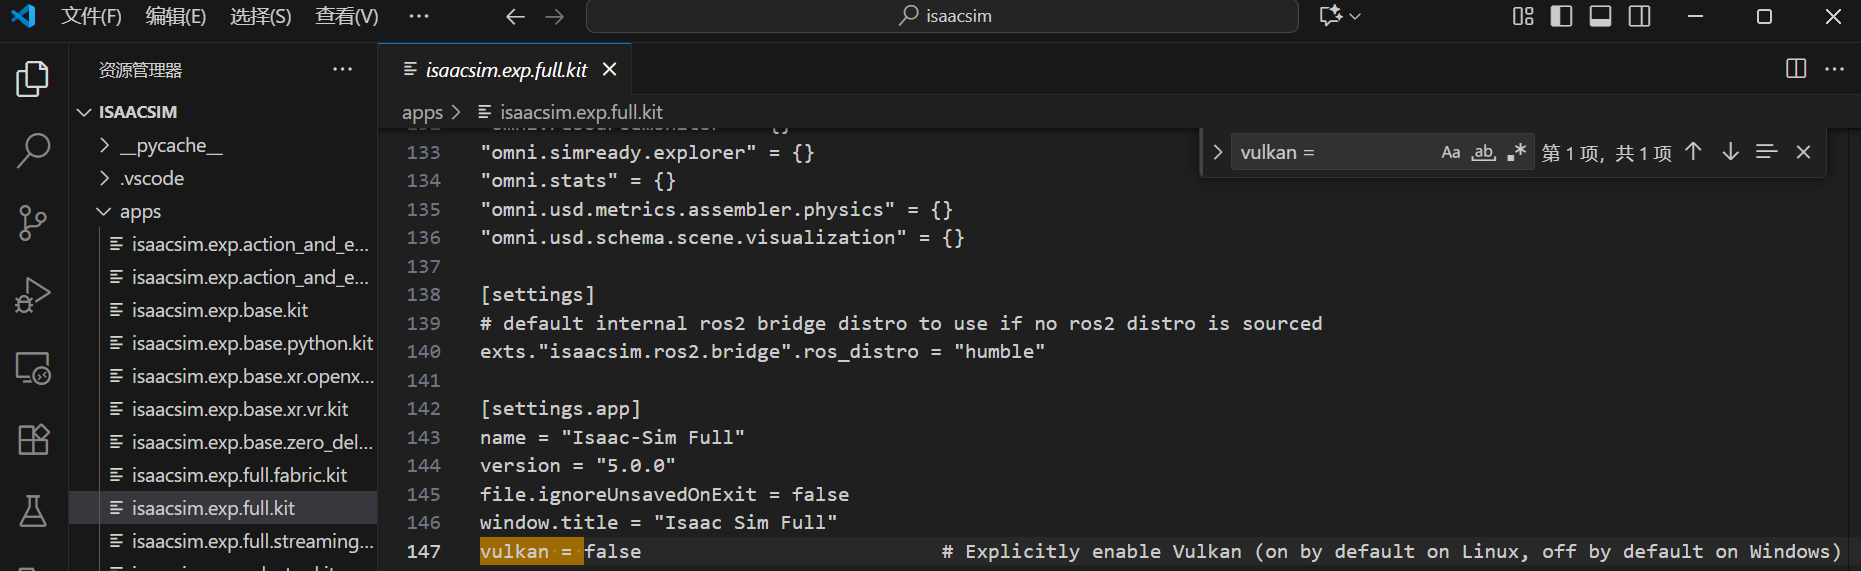

---


## (2) 配置VSCode
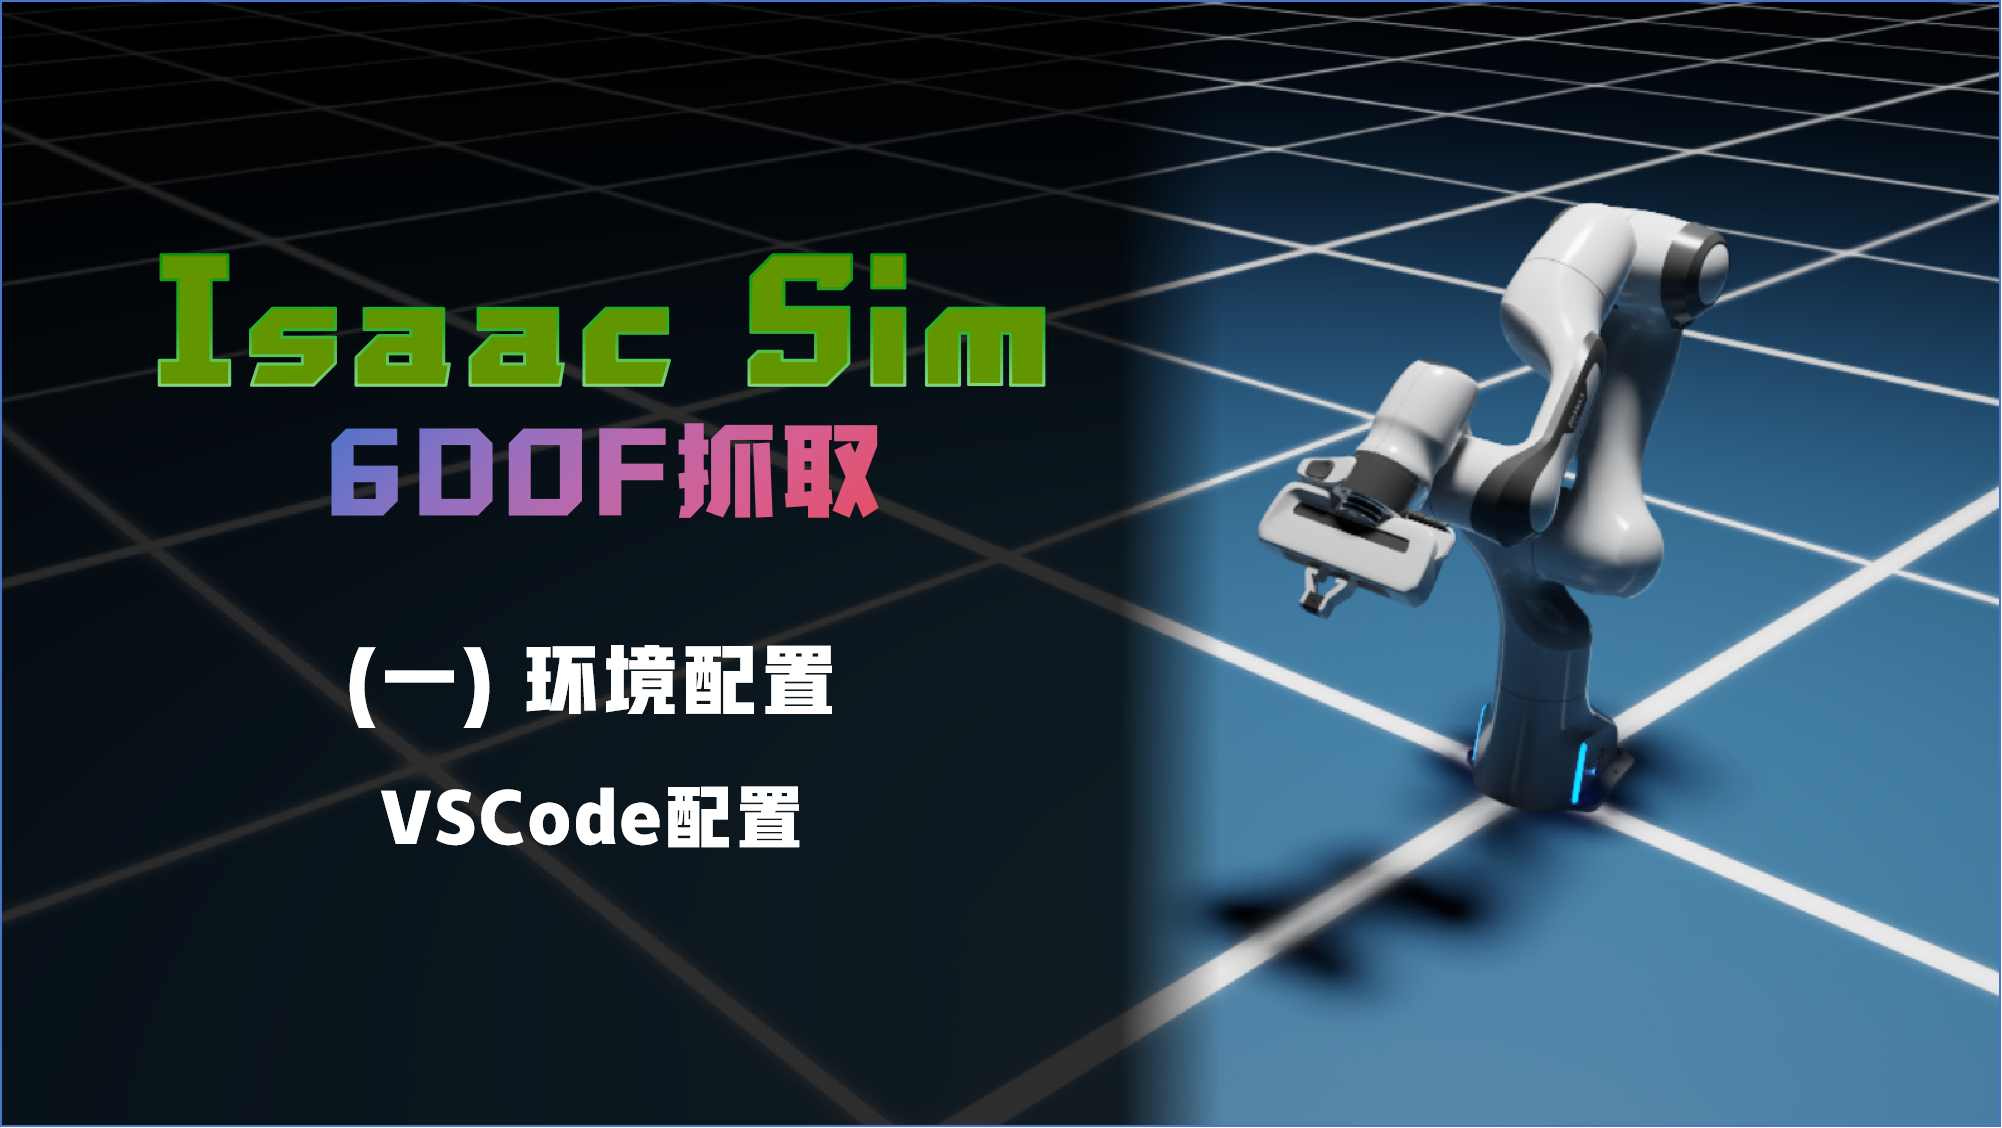
主要内容包括：
* 安装VSCode插件
* 配置Conda环境自动激活(可选)
* 配置VSCode联动IsaacSim
* 配置VSCode代码提示与跳转

### 1. 安装VSCode插件
* Python插件
  一般我们使用Python开发，安装如下插件以实现VSCode对Python的语言支持和代码调试

  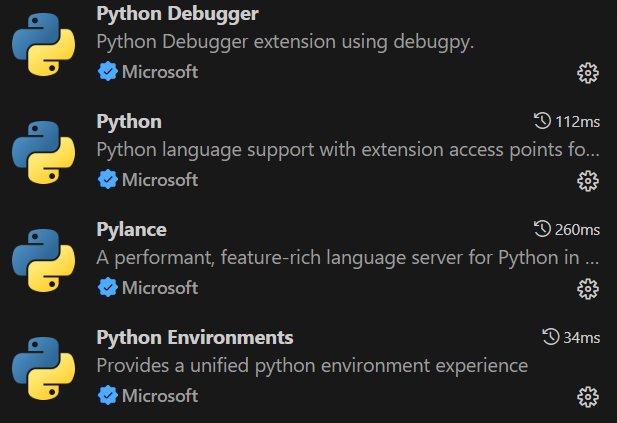

* IsaacSim插件
  该插件是IsaacSim官方提供的VSCode插件，提供了代码执行、代码片段示例、API快速列表以及在线文档查看

  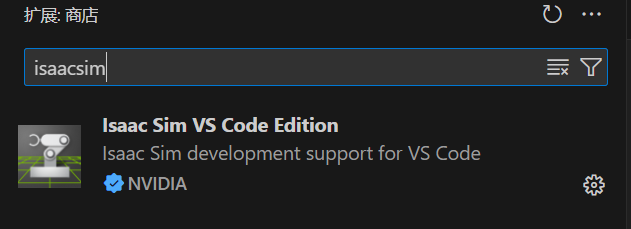

--- 

### 2. 配置Conda环境自动激活

 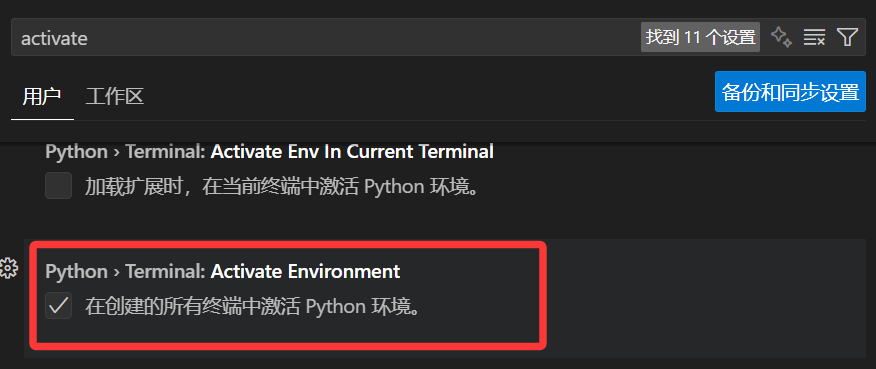
 
 选择了Python环境后，创建新终端会自动激活该环境，很方便

---

### 3. 配置VSCode联动IsaacSim
#### IsaacSim调起VSCode
启用IsaacSim的VSCode集成插件，然后Window选项卡中会出现VScode按钮，点击按钮会自动启动VSCode打开IsaacSim的代码目录
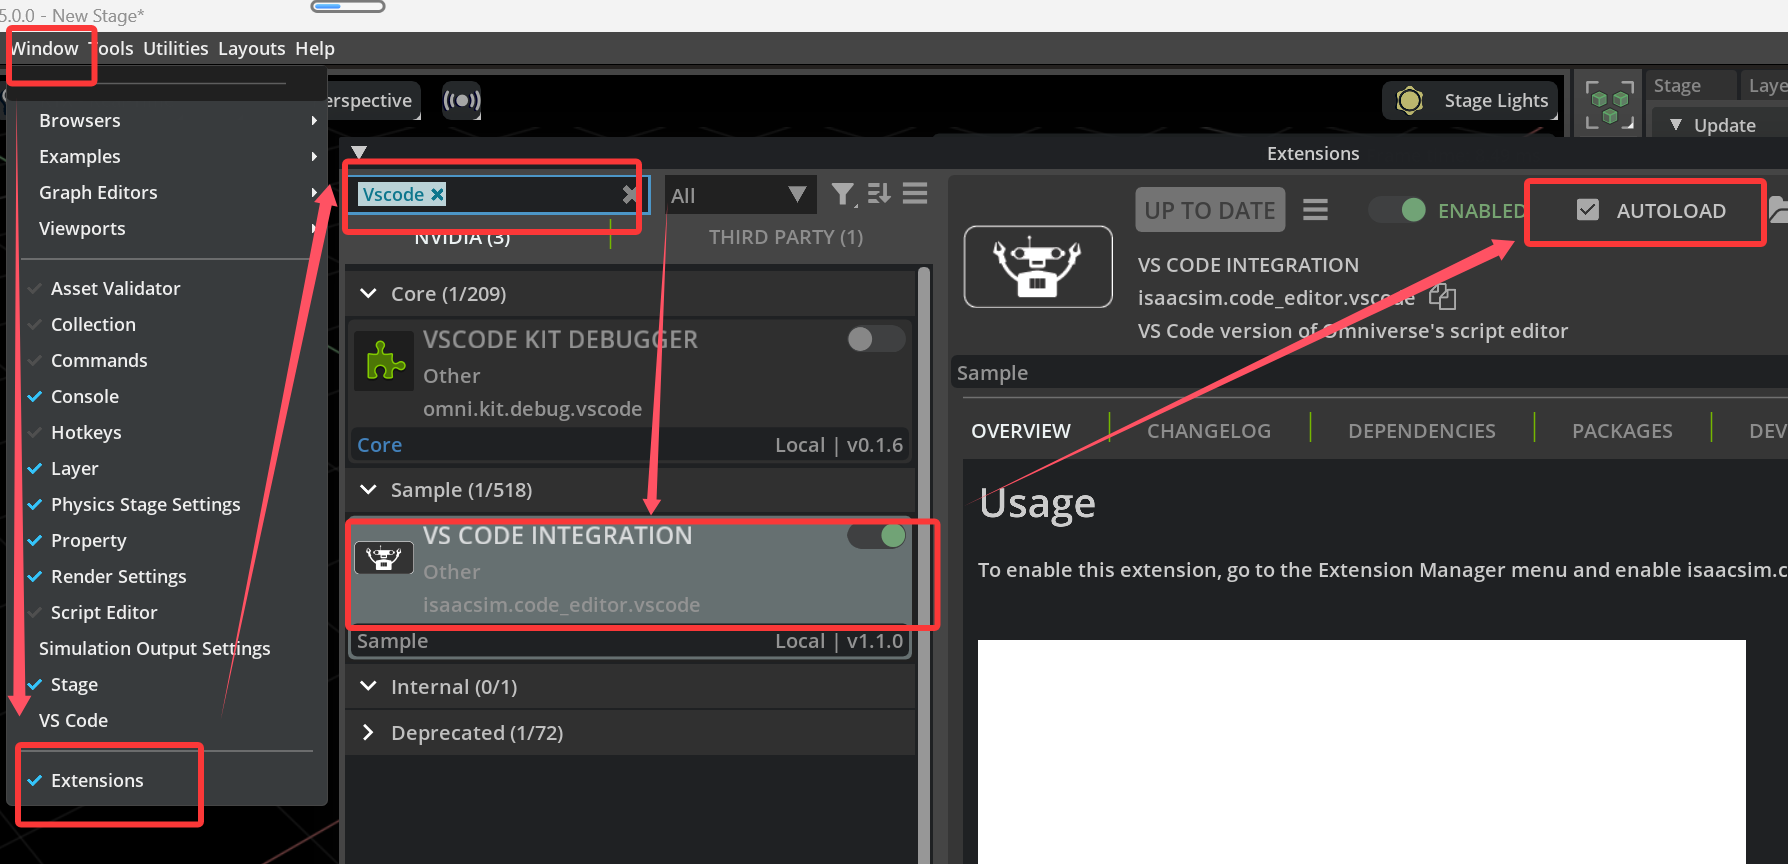

#### 配置VSCode调试IssaSim
首先启用IsaacSim的VSCode调试插件

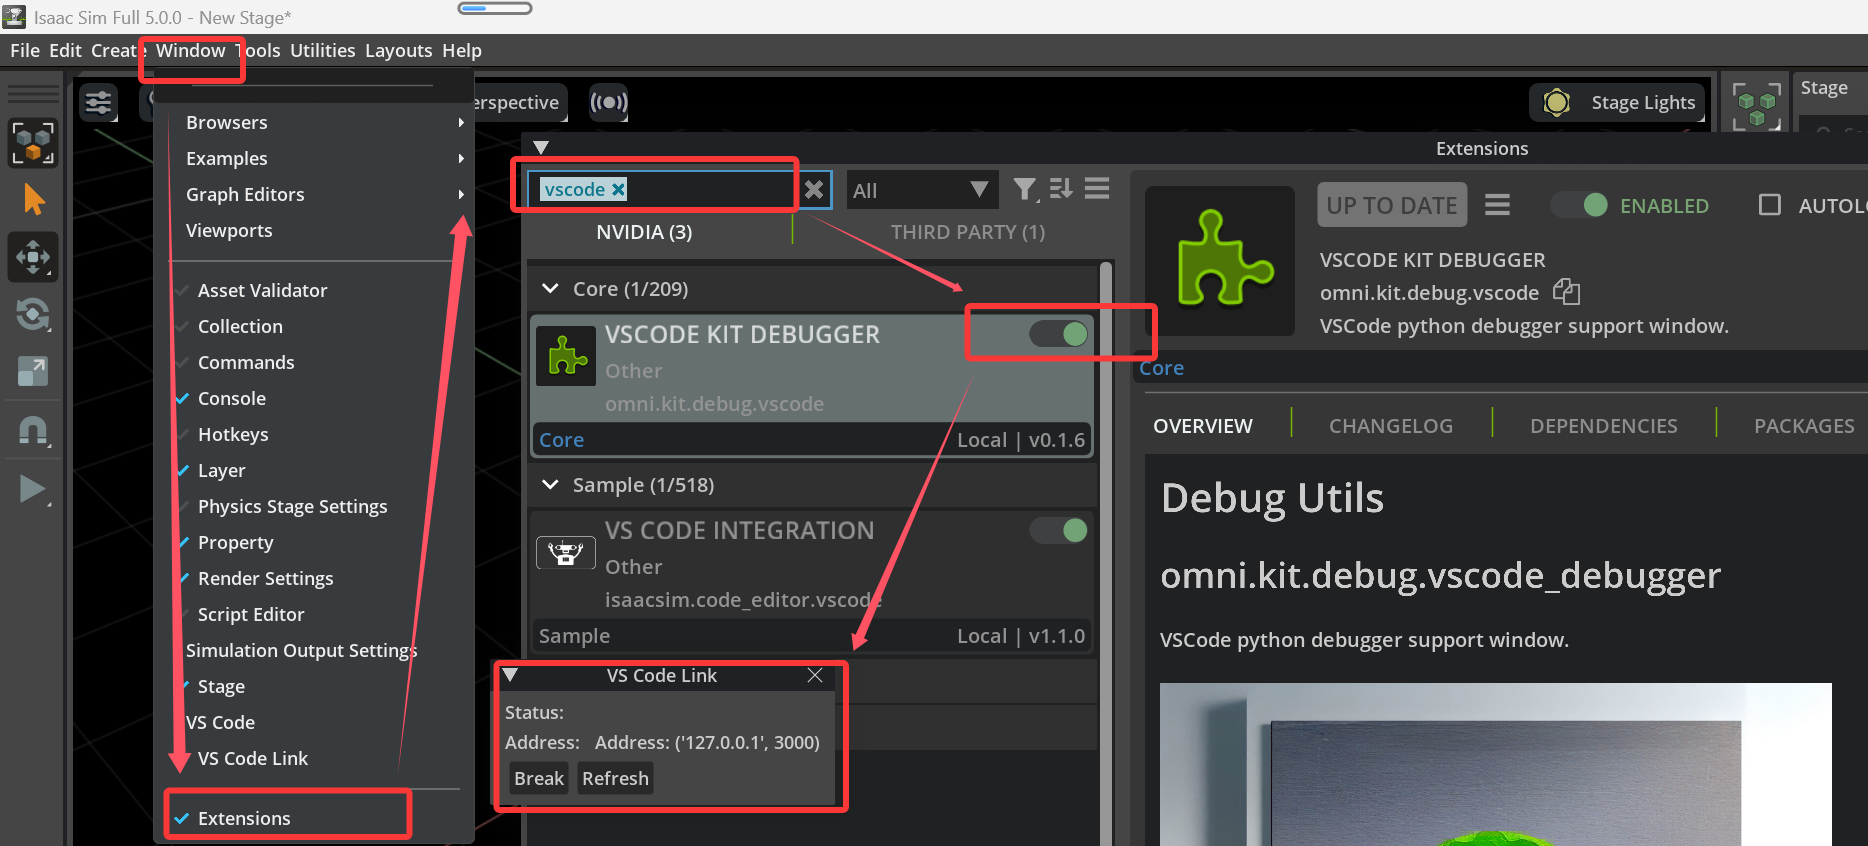

然后配置.vscode/launch.json文件，配置调试项

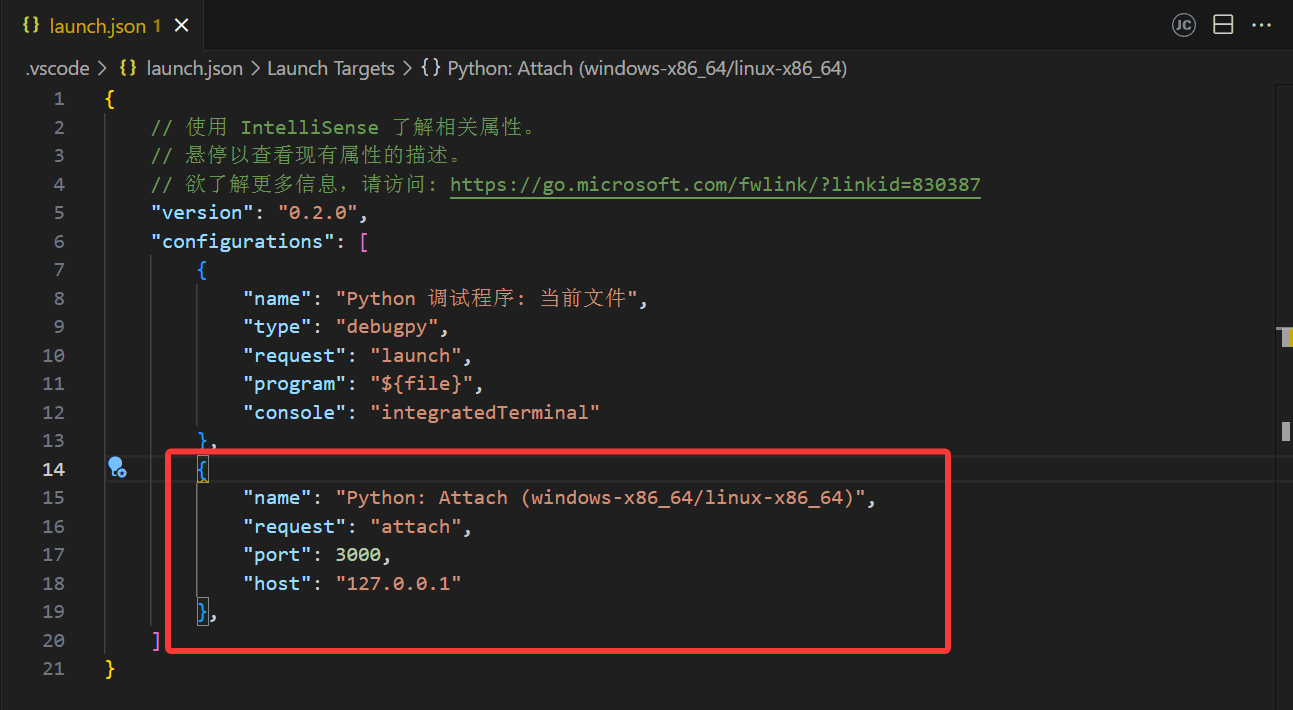

点击VSCode的调试按钮，选择刚才配置的IsaacSim调试项，点击启动。

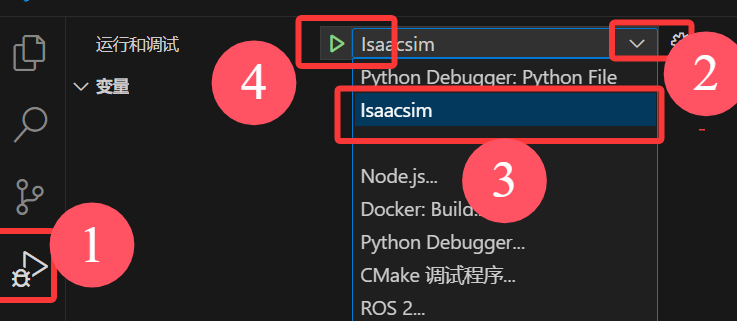

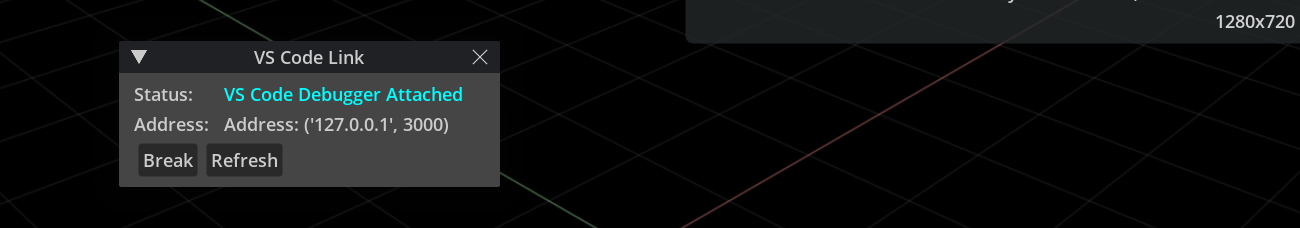

---

### 4. 配置IsaacSim代码提示与跳转
  我们在IsaacSim的VSCode插件可以看到，IsaacSim提供了很多python API，但是VSCode无法识别。
  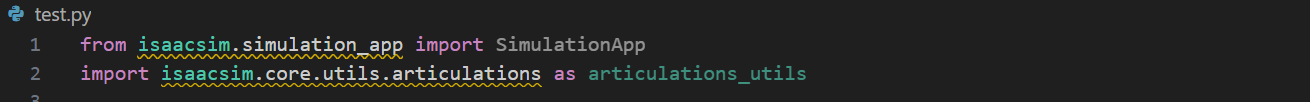

  我们需要运行IsaacSim提供的脚本生成VSCode的配置文件
  
  ```bash
  python -m isaacsim --generate-vscode-settings
  ```

  运行该命令会生成VSCode的配置文件./vscode/settings.json，其中的
    "python.defaultInterpreterPath": 
    "python.analysis.extraPaths" 
  配置了IsaacSim的Python环境，以及IsaacSim的API路径，这样IsaacSim的代码提示与跳转就会生效

  > **值得注意的是，在Windows系统下默认生成的配置中路径的分割符是是反斜杠\，需要改成正斜杠/**，配置才会生效

  生效后效果
  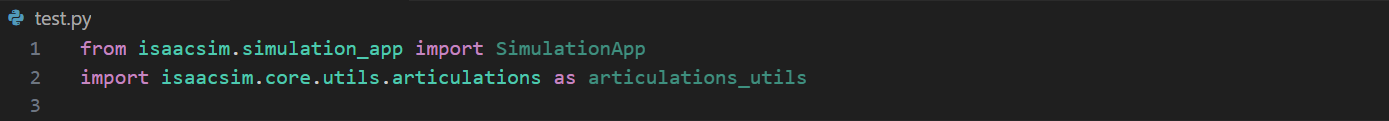

## (3) 配置本地资产包
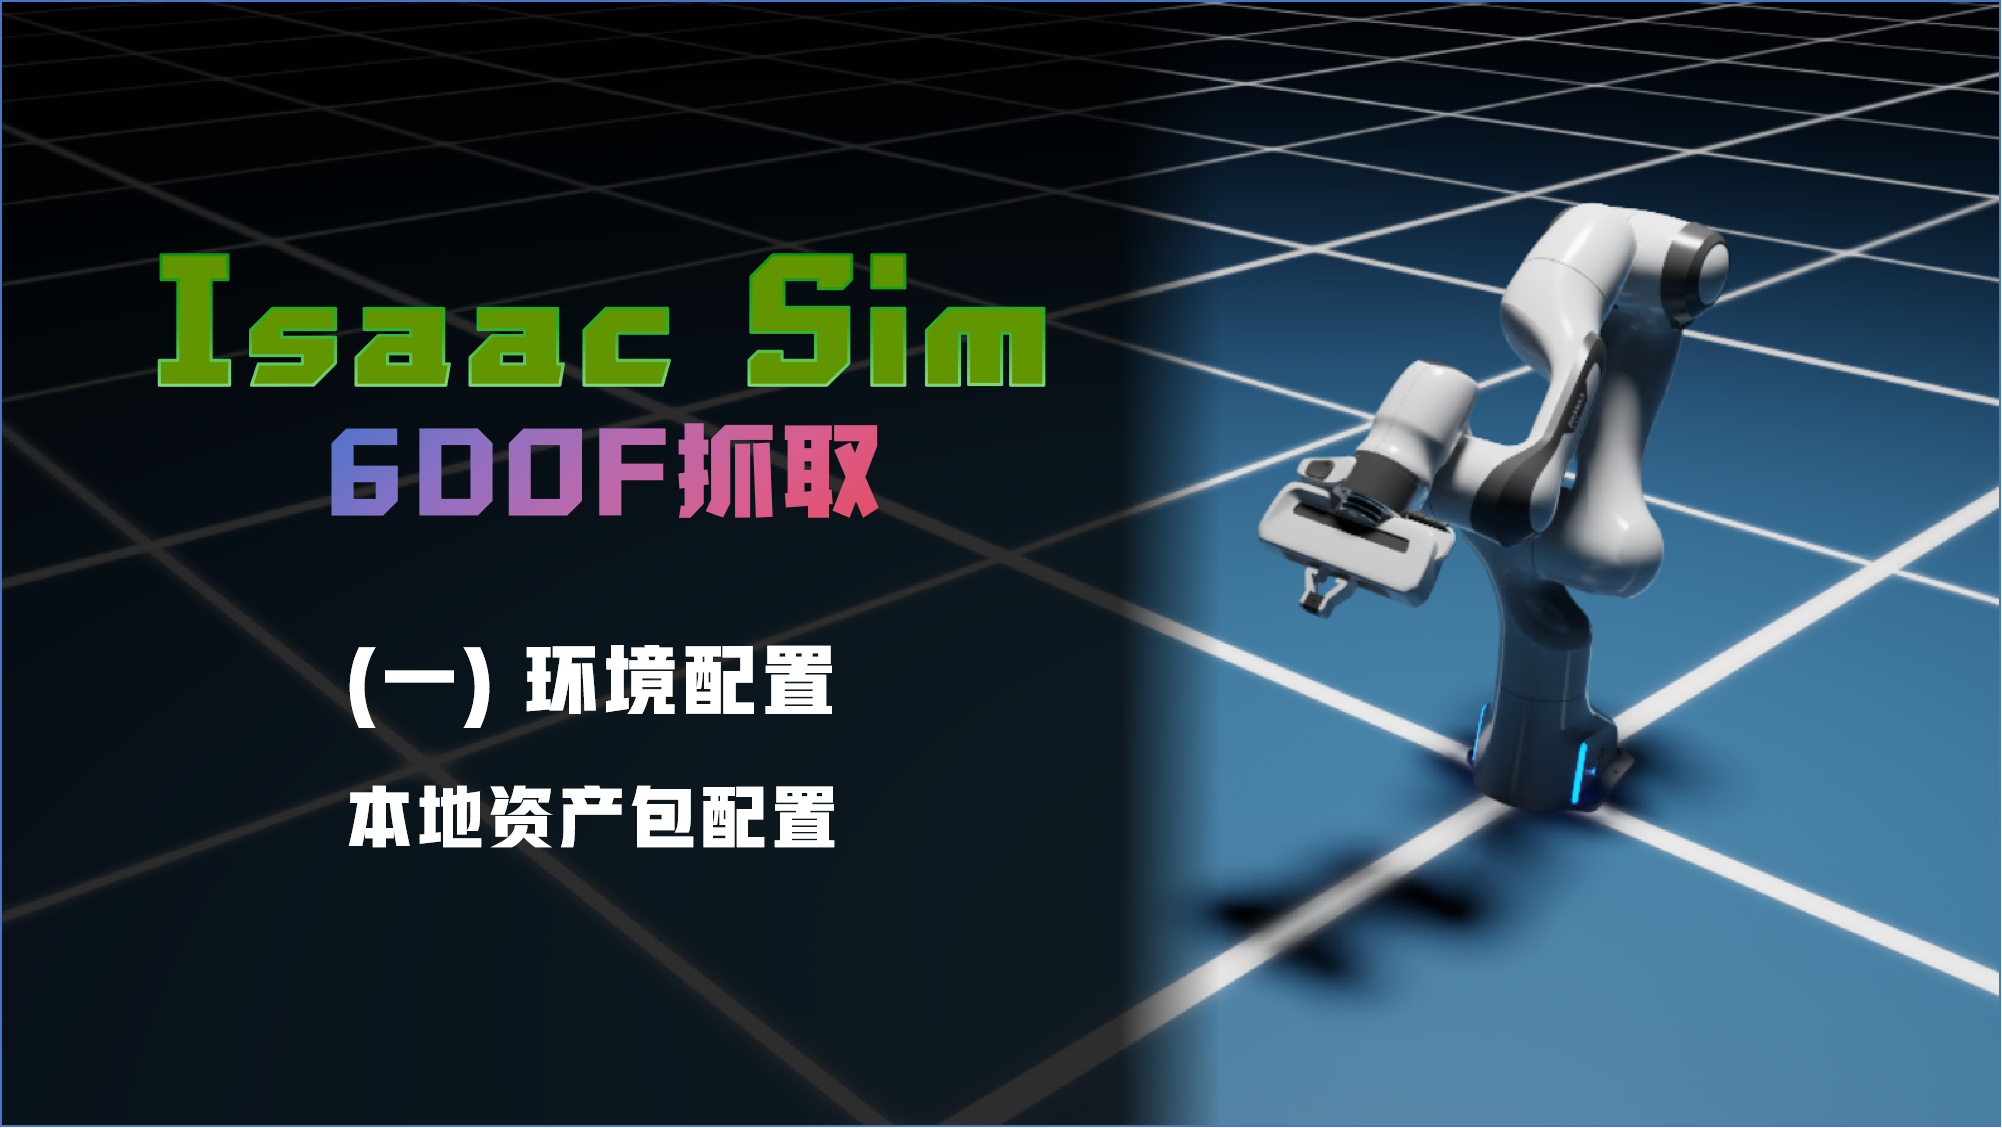
本节带着大家下载IsaacSim资产包，然后配置本地加载本地资产源。

isaacsim官方提供了丰富的机器人和环境的资产文件，我们在isaacsim的IsaacSim Assets里可以看到。
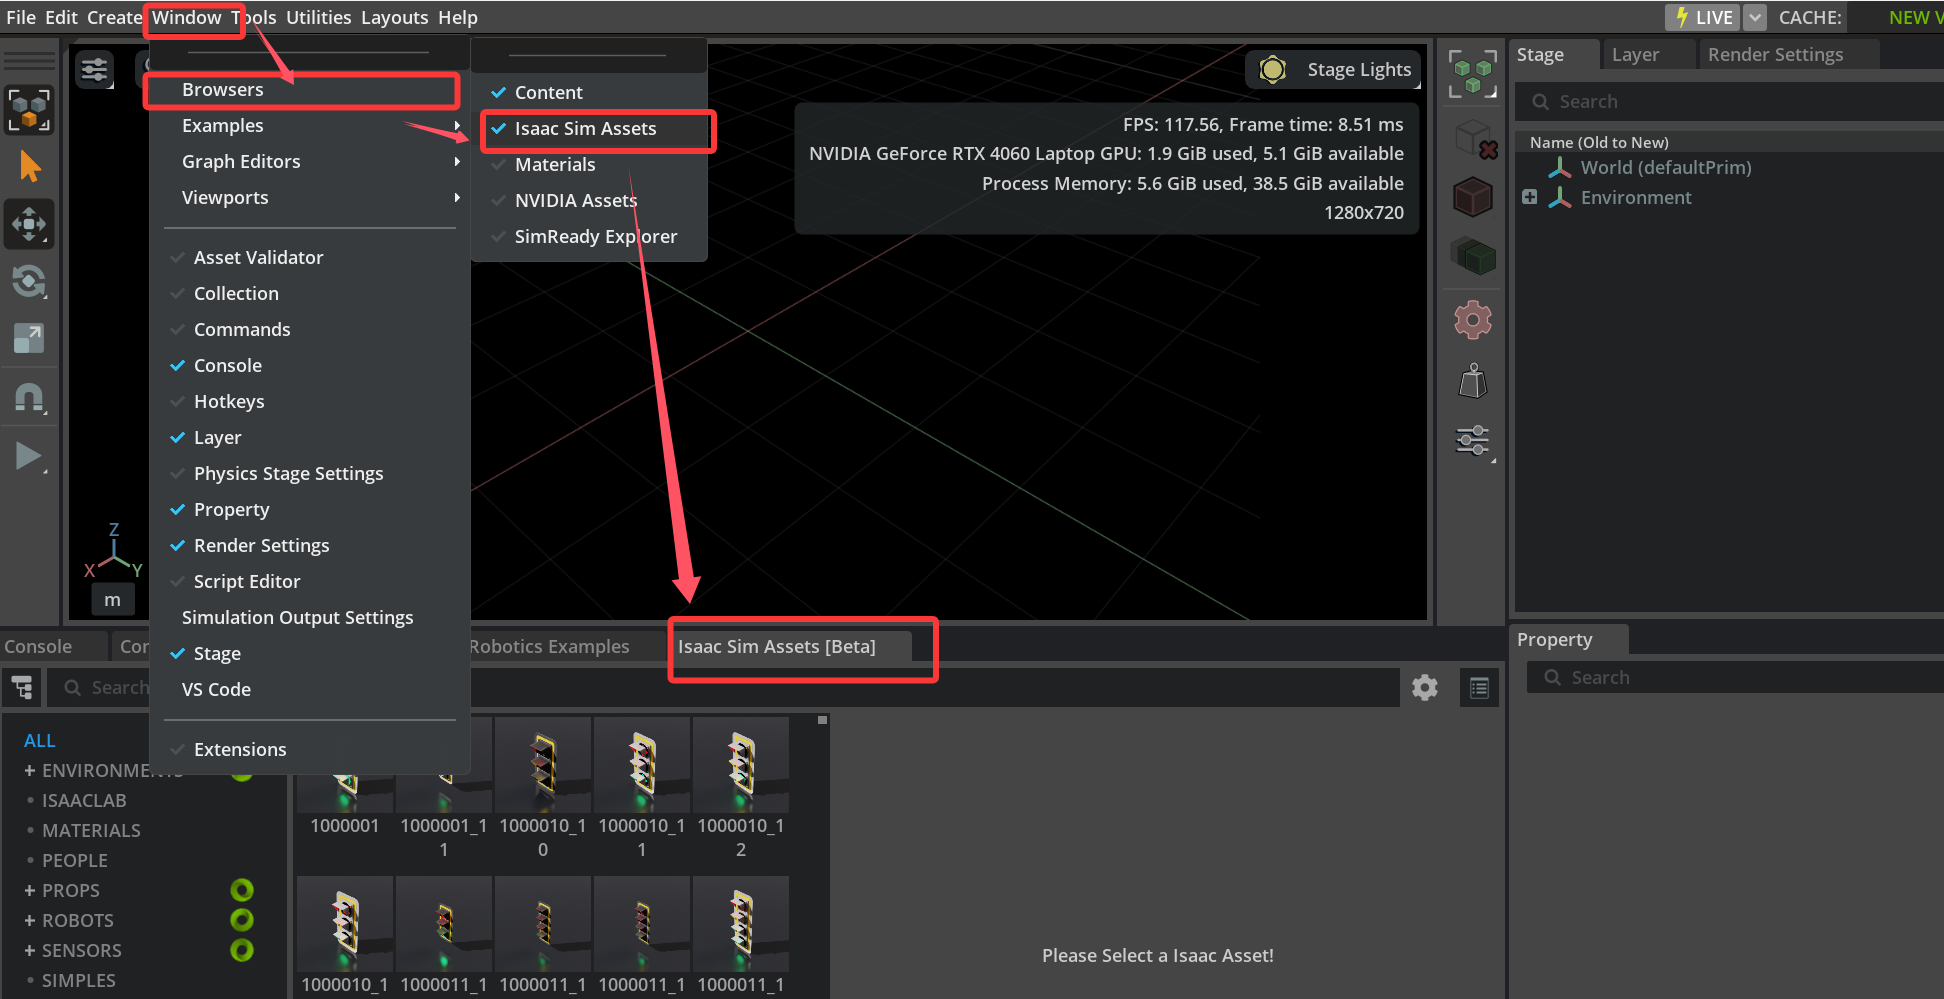

当我们加载这些资产时，如果本地没有该文件，isaacsim就会阻塞当前程序，然后访问默认的资产源进行下载，但是isaacsim的默认资产源是 https://omniverse-content-production.s3-us-west-2.amazonaws.com/Assets/Isaac/5.0 这个源的服务器在美国西部的aws节点，下载速度就会很慢。
那么整个程序就表现为长时间的卡死，非常地影响开发体验。
所以建议将资产包下载到本地，然后配置本地资产源。

### 1. 下载资产包
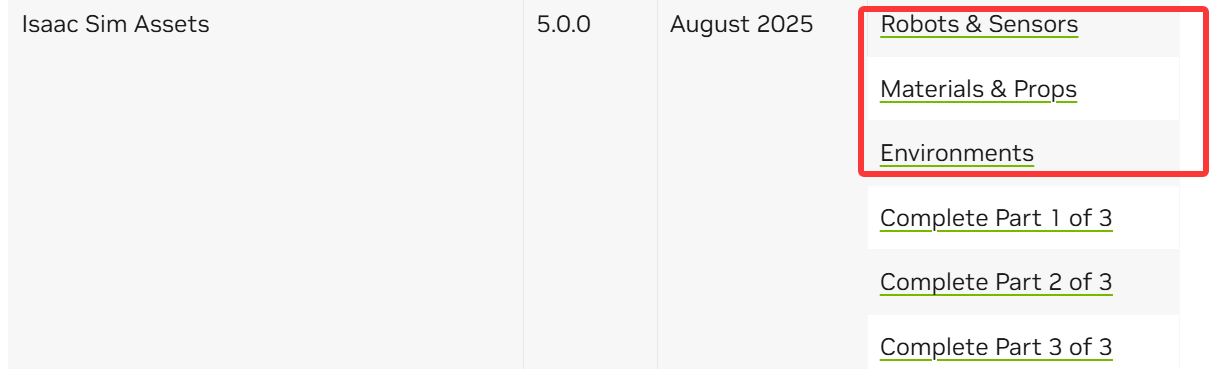

### 2. 配置本地资产源
下载三个压缩包后，我们可以将这三个压缩包解压到同一个目录下，然后配置本地资产源。
例如：
1. 首先在D盘创建一个isaacsim_assets目录
2. 然后将所有的资产包解压到D:/isaacsim_assets目录下
3. 这样D:/isaacsim_assets目录就是本地资产源

然后打开isaacsim的安装路径，在apps/isaacsim.exp.base.kit文件最后面，添加如下的内容：
```toml

[settings]
persistent.isaac.asset_root.default = "D:/isaacsim_assets/Assets/Isaac/5.0"

exts."isaacsim.asset.browser".folders = [
    "D:/isaacsim_assets/Assets/Isaac/5.0/Isaac/Robots",
    "D:/isaacsim_assets/Assets/Isaac/5.0/Isaac/People",
    "D:/isaacsim_assets/Assets/Isaac/5.0/Isaac/IsaacLab",
    "D:/isaacsim_assets/Assets/Isaac/5.0/Isaac/Props",
    "D:/isaacsim_assets/Assets/Isaac/5.0/Isaac/Environments",
    "D:/isaacsim_assets/Assets/Isaac/5.0/Isaac/Materials",
    "D:/isaacsim_assets/Assets/Isaac/5.0/Isaac/Samples",
    "D:/isaacsim_assets/Assets/Isaac/5.0/Isaac/Sensors",
]

exts."isaacsim.gui.content_browser".folders = [
    "D:/isaacsim_assets/Assets/Isaac/5.0/Isaac/Robots",
    "D:/isaacsim_assets/Assets/Isaac/5.0/Isaac/People",
    "D:/isaacsim_assets/Assets/Isaac/5.0/Isaac/IsaacLab",
    "D:/isaacsim_assets/Assets/Isaac/5.0/Isaac/Props",
    "D:/isaacsim_assets/Assets/Isaac/5.0/Isaac/Environments",
    "D:/isaacsim_assets/Assets/Isaac/5.0/Isaac/Materials",
    "D:/isaacsim_assets/Assets/Isaac/5.0/Isaac/Samples",
    "D:/isaacsim_assets/Assets/Isaac/5.0/Isaac/Sensors",
]
```

